# Solving sudokus with BrainScaleS-2

In this task we want to apply our newly gained knowledge to a well-known problem:
We will deal with solving a sudoku on spiking hardware.

If you never before encountered this logic puzzle from 1984, let’s define the rules.
Usually you have a 9x9 square grid and the goal is to fill in numbers from 1 to 9, given crucial constraints:

1. In each row, each number is only allowed exactly once.  
1. In each column, each number is only allowed exactly once.  
1. In each 3x3 sub grid, each number is only allowed exactly once.  


To find a valid solution, hints are given in form of given, fixed numbers.
An obvious strategy for solving a sudoku is to, sequentially, find a square where only one number is allowed.
This seems trivial but due to the high dimensionality finding a solution is a non-trivial task.
However, checking the correctness of a potential solution is a simple task.
To circumvent the slowness of a brute-force solution one can resort to a stochastic strategy.
In fact, a spiking neuronal network (SNN) can accomplish this task in this manner quickly and with high precision.

The basic idea in creating a sudoku solver with an SNN is to assign to each possible number in each field one neuron, called one-hot encoding.
In our case, each field would have four neurons representing the numbers 1 to 4, respectively.
A neuron being active is interpreted as that field being filled with the respective number, consequently a given, hinted number is represented by a continuously spiking neuron.
An excluding constraint will be realised with an inhibitory synapse due to the suppressing effect on the activity.
To allow the network to explore different states, a random Poisson-distributed background noise is applied to all neurons.
In addition, each neuron is excitatorily connected to itself to maintain possible activity.

Let’s start with a simplified version of a sudoku with a 4x4 grid, as shown in the figure.

Assume the grey three is given, applying the previously mentioned constraints we obtain:

- Due to 1, the purple threes are not allowed.  
- Due to 2, the green threes are not allowed.  
- Due to 3, the blue threes are not allowed.  
- Due to the choice of our encoding, the orange numbers are not allowed (in each field only one number is allowed to be active)  



<a id='sudoku'></a>
<img src="./static/sudoku.png" style="width:40%;">

Representation of a 4x4 sudoku with one-hot encoding:
In each small square, each number from 1 to 4 has one respective neuron;
four small squares, framed by the thick line, make one block in the original sudoku;
there are four such blocks to complete the 4x4 sudoku.  
For further information read into [Solving the Constraint Satisfaction Problem Sudoku on Neuromorphic Hardware (MA Thesis)](https://www.kip.uni-heidelberg.de/Veroeffentlichungen/download.php/6118/temp/3666.pdf).

## Experiment setup

Initially we have to connect to the scheduling service and load required packages

In [1]:
from _static.common.helpers import setup_hardware_client
setup_hardware_client()

INFO  15:27:55,457  demo_helpers Connection to hxcube7fpga0chip57_1 established


In [2]:
from collections import OrderedDict
from functools import partial
from typing import Callable
from itertools import product

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.style.use("_static/matplotlibrc")

# Turn off tight_layout/autolayout
plt.rcParams["figure.autolayout"] = False
# Enable modern constrained_layout
plt.rcParams["figure.constrained_layout.use"] = True

from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

import pynn_brainscales.brainscales2 as pynn
from pynn_brainscales.brainscales2.standardmodels.synapses import StaticSynapse
from pynn_brainscales.brainscales2.standardmodels.cells import SpikeSourceArray, HXNeuron,SpikeSourcePoisson

from IPython.display import display
from ipywidgets import interactive, IntSlider, FloatSlider, Layout, VBox, Box, HTML

from _static.common.helpers import get_nightly_calibration

calib = get_nightly_calibration()
pynn.setup(initial_config=calib)

%matplotlib inline

We start by creating a population with the required number of neurons. Additionally, we create a view for each field to facilitate easier access later
`pops_collector[row][field][neuron]`

In [3]:
# Defining total runtime and dimensionality of sudoku
runtime = 0.5
dimension = 4

# this sudoku shall be solved
global sudoku
sudoku = np.array([
    [3, 2, 4, 1],
    [1, 4, 3, 2],
    [2, 3, 1, 4],
    [4, 1, 2, 3]
])

# dimension = 9
# sudoku = np.array([
#     [1,2,3,4,5,6,7,8,9],
#     [4,5,6,7,8,9,1,2,3],
#     [7,8,9,1,2,3,4,5,6],
#     [2,3,1,6,7,4,8,9,5],
#     [8,7,5,9,1,2,3,6,4],
#     [6,9,4,5,3,8,2,1,7],
#     [3,1,7,2,6,5,9,4,8],
#     [5,4,2,8,9,7,6,3,1],
#     [9,6,8,3,4,1,5,7,2]
# ])

# -> we need dimension (rows) * dimension (columns) * dimension (numbers) = dimension^3 neurons
pop = pynn.Population(dimension**3, HXNeuron())
pop.record("spikes")

# to define the connections easier, we save a "view" of each neuron in a list
pops_collector = []
for row in range(dimension):
    pops_row = []
    for field_in_row in range(dimension):
        pops_field = []
        for number_in_field in range(dimension):
            neuron = pynn.PopulationView(
                pop,
                [row * dimension**2 + field_in_row * dimension + number_in_field])
            pops_field.append(neuron)
        pops_row.append(pops_field)
    pops_collector.append(pops_row)

# we do NOT define a pops_collector as  3d list containing "view" objects of each neuron in the population
# instead we save the indices of the neurons in the population [for index in range(0, dim**3 - 1)] in a 3d np.array
# we can slice the population of neurons using pop[list(neuron_indices[x, y, z])]
neuron_indices = np.arange(dimension**3).reshape((dimension, dimension, dimension))

In [4]:
# Create background noise
poisson_source = pynn.Population(
    dimension**3,
    SpikeSourcePoisson(
        duration = runtime - 0.01,
        rate = 5e5,
        start = 0.01
    )
)

# connect random sources with neurons
# additionally each neuron is connected to itself excitatorily to
# sustain possible activity
pynn.Projection(
    pop,
    pop,
    pynn.OneToOneConnector(),
    synapse_type = StaticSynapse(weight = 20),
    receptor_type = 'excitatory'
)
pynn.Projection(
    poisson_source,
    pop,
    pynn.OneToOneConnector(),
    synapse_type = StaticSynapse(weight = 30),
    receptor_type = 'excitatory'
);

In [5]:
# create stimulation for clues and connect to according neurons
stim_given_numbers = pynn.Population(
    1,
    SpikeSourceArray(
        spike_times = np.linspace(0.0, runtime, 500)
    )
)

clue_projections = []

for row in range(4):
    clues_row = []
    for column in range(4):
        clues_field = []
        for number in range(4):
            clues_field.append(
                pynn.Projection(
                    stim_given_numbers,
                    pops_collector[row][column][number],
                    pynn.AllToAllConnector(),
                    synapse_type = StaticSynapse(weight = 0),
                    receptor_type = 'excitatory'
                )
            )
        clues_row.append(clues_field)
    clue_projections.append(clues_row)

In [6]:
# functions to solve the sudoku:
def set_clues(clues = None):
    """Sets the clues in the network."""
    if clues is None:
        clues = np.zeros((4, 4), dtype=int)
    for row, row_clues in enumerate(clue_projections):
        for col, field_clues in enumerate(row_clues):
            for number, clue_projection in enumerate(field_clues, start=1):
                for connection in clue_projection:
                    if clues[row,col] == number:
                        connection.weight = 63.0
                    else:
                        connection.weight = 0.0

def hide_solution(grid, num_clues, seed = None):
    """Hides the solution and only leaves `num_clues` hints."""
    indices = np.argwhere(np.logical_and(grid > 0, grid <= 4))
    if len(indices) < num_clues:
        raise RuntimeError(f"The sudoku has less than {num_clues} clues, which is the number of required clues :(")
    np.random.seed(seed)
    indices = indices[np.random.choice(len(indices), num_clues, replace=False)]
    clues = np.zeros_like(grid)
    clues[(indices.T[0], indices.T[1])] = grid[(indices.T[0], indices.T[1])]
    return clues

def get_solution(runtime, clues):
    """Executes the network and returns the current solution."""
    set_clues(clues)
    grid = np.zeros((4, 4), dtype=int)

    # Define duration of poisson spikes
    poisson_source.set(duration = runtime - 0.01)

    # emulate the network
    pynn.reset()
    pynn.run(runtime)
    # read back solution
    for row, row_populations in enumerate(pops_collector):
        for col, field_populations in enumerate(row_populations):
            num_spikes = [
                len(num_population.get_data("spikes").segments[-1].spiketrains[0]) for num_population in field_populations
            ]
            grid[row, col] = np.argmax(num_spikes) + 1
    return grid

In [7]:
# we code the inhibitors in a separate file as well and import only the overarching set_constraints function
from sudoku.inhibitors import set_constraints

# we put the build_gui function and the SudokuPlotter class in their own .py files to compact the notebook
from sudoku.gui_builder import build_gui
from sudoku.sudoku_plotting import SudokuPlotter

### Running the network **without** the constraints:

In [8]:
SP: SudokuPlotter = SudokuPlotter(dimension, pop, set_clues, hide_solution, get_solution)
# The cell below will only work, of course, if you implemented the correct constraints above.
# Red/green frame show (in)correctness of the proposed solution (consistency with the given sudoku).

def experiment(**kwargs):
    SP.solve_sudoku(
        sudoku,
        kwargs["runtime"],
        kwargs["num_clues"],
        kwargs["random_seed"]
    )
    SP.plot(grid = True, savefig_name = None)

def experiment_save(**kwargs):
    SP.solve_sudoku(
        sudoku,
        kwargs["runtime"],
        kwargs["num_clues"],
        kwargs["random_seed"]
    )
    SP.plot(grid = True, savefig_name = kwargs['savefig_name'])

build_gui(
    experiment,
    ["num_clues", "random_seed", "runtime"]
)

None


xlim Values: (-0.019759600000000002, 0.5245995999999999)


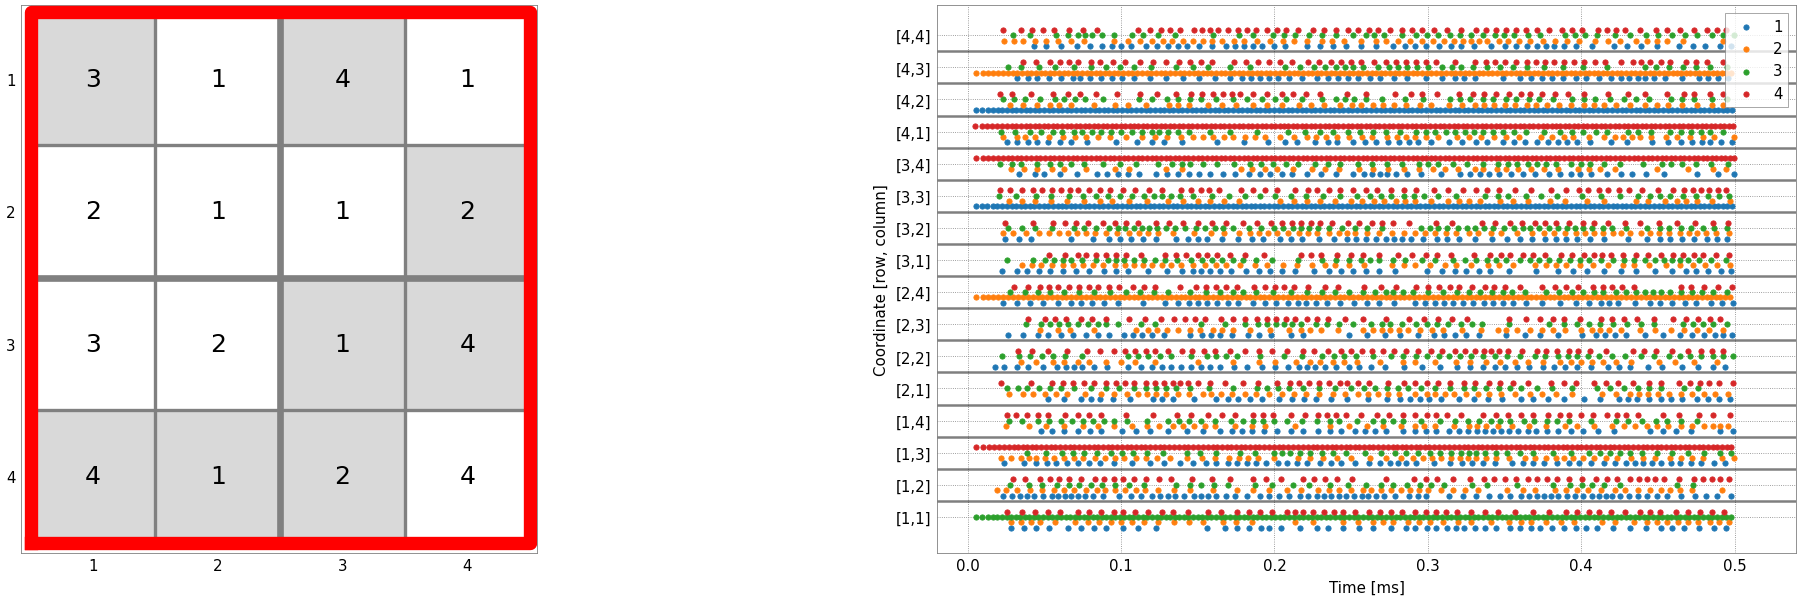

In [9]:
# run an example and save the figure
experiment_save(
    runtime = 0.5,
    num_clues = 8,
    random_seed = 1234,
    savefig_name = 'no_constraints_sudoku.png'
)

### Running the network **with** the constraints:

In [10]:
SP: SudokuPlotter = SudokuPlotter(dimension, pop, set_clues, hide_solution, get_solution)

# The cell below will only work, of course, if you implemented the correct constraints above.
# Red/green frame show (in)correctness of the proposed solution (consistency with the given sudoku).

set_constraints(pop, neuron_indices, dimension)

build_gui(experiment, ["num_clues", "random_seed", "runtime"])

None


xlim Values: (-0.0197704, 0.5242983999999999)


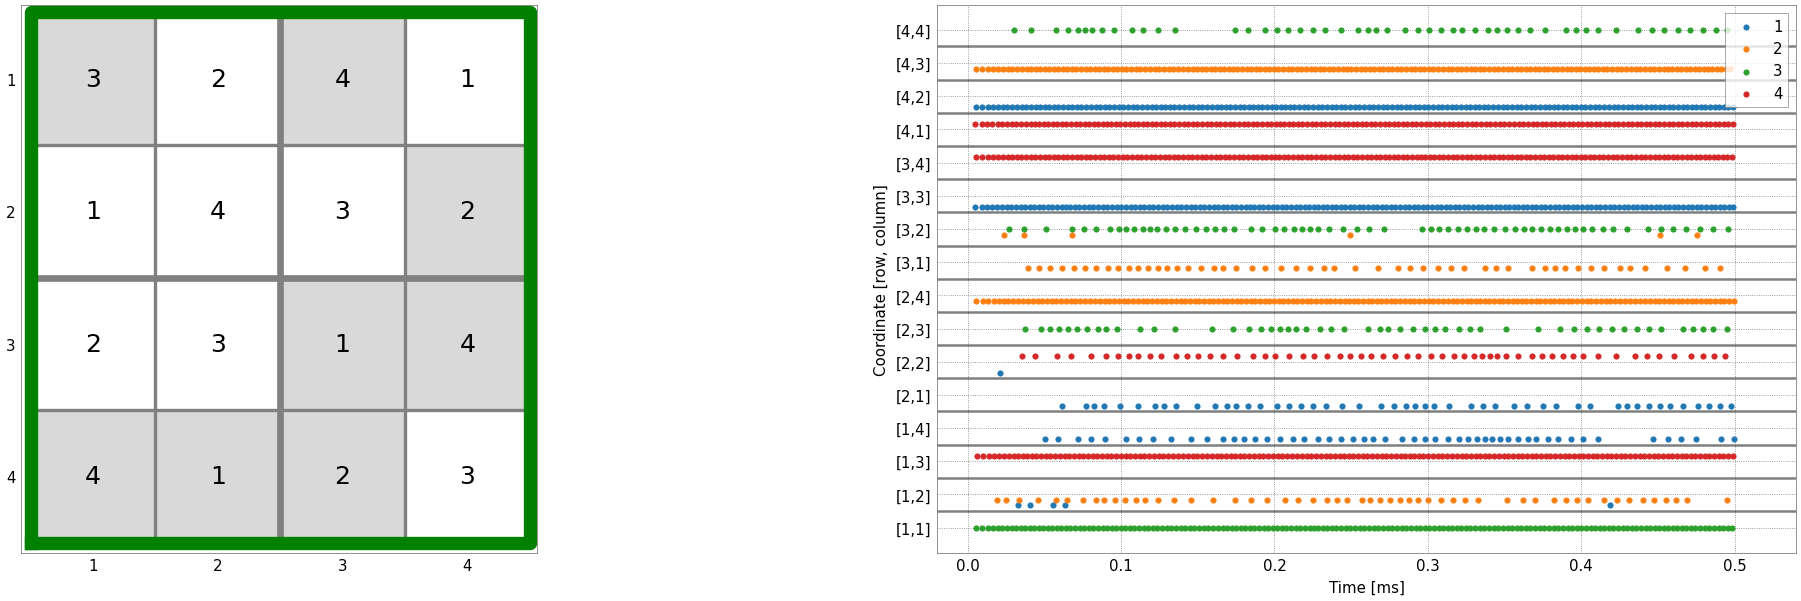

In [11]:
# run an example and save the figure
experiment(
    runtime = 0.5,
    num_clues = 8,
    random_seed = 1234,
    savefig_name = 'with_constraints_sudoku.png'
)

The hardware will try to solve the given sudoku.
If you want to implement your own sudoku with unknown numbers you can enter 0 as an empty field.
(*Hint*: When you change the sudoku, rerun the cell)

The hints are chosen randomly. By varying the seed you vary the position of the clue and by changing the number the sudoku changes the difficulty.

## Exercises

- **Task 1:**
  Run the network without any constrains, observe the spike pattern and the solution of the sudoku.
  Try to explain.  


- **Task 2:**
  Now implement the four constraint rules discussed above.
  If they are correctly implemented you should get a solved sudoku (keep number of hints and seed).  


Now you have a working sudoku solver. Let’s test it:

- **Task 3:**
  Vary the number of clues.
  If the solver fails can you find an explanation for that behavior?
  Can you think of possible strategies to reduce such errors?
  (*It might help to inspect the code and numpy documentation*)  


- **Task 4:**
  What do you expect to happen, if you set the number of clues to zero?
  Check your hypothesis.
  Can you explain your observation?  


- **Task 5:**
  Now, investigate how the success rate is related to the number of clues.
  For this, vary the number of clues from four to ten.
  Repeat each configuration ten times, while keeping the sudoku fixed.
  Visualize your result.  
- **Task 6:**
  Is there a constraint that is not necessarily required?
  Why?  


- **Task 7:**
  Crunching some numbers:
  How many neurons and how many synaptic connections were required in this task?
  How many would be required for a 9x9 sudoku?  

In [12]:
def experiment2(**kwargs):
    SP.solve_sudoku(
        sudoku,
        kwargs["runtime"],
        kwargs["num_clues"],
        kwargs["random_seed"]
    )
    return SP.solved_sudoku_correct

clues = np.arange(4, 11)
num_trials = 10
# initialize array, with -1 as an error detection value
# writing True or False to an element puts a 1 or 0 there
results = np.array([[-1] * num_trials] * len(clues))

for i, num_clues in enumerate(clues):
    for j in range(num_trials):
        seed = int(np.random.random_sample() * 1000)
        results[i][j] = experiment2(runtime = 0.5, num_clues = num_clues, random_seed = seed)
    print(f'Completed trials for {num_clues} clues.')
print('Finished!')
print('Results:')
print(results)

Completed trials for 4 clues.
Completed trials for 5 clues.
Completed trials for 6 clues.
Completed trials for 7 clues.
Completed trials for 8 clues.
Completed trials for 9 clues.
Completed trials for 10 clues.
Finished!
Results:
[[0 1 0 0 0 1 1 1 0 1]
 [1 0 1 1 1 1 1 0 1 1]
 [1 1 1 0 1 0 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]]


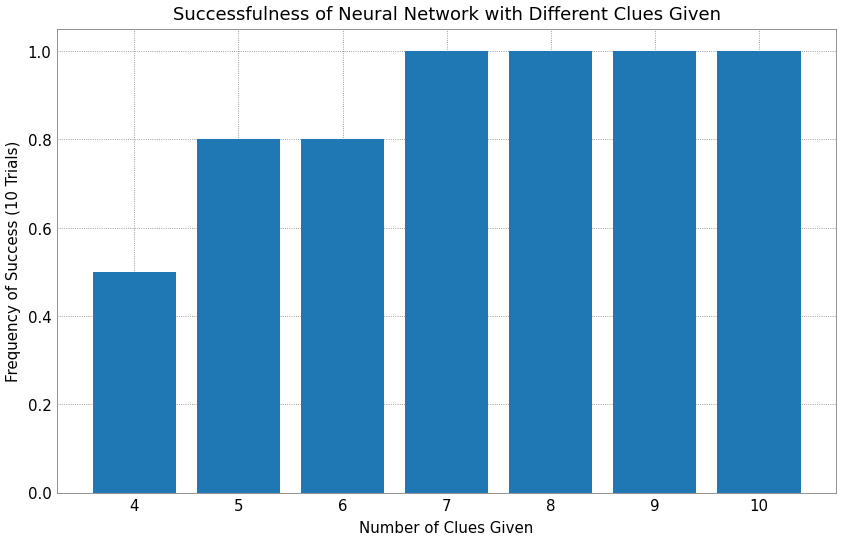

In [13]:
# sum up successes of all trials at constant clue number (divide by total trials)
success_count = [np.sum(trials)/num_trials for trials in results]

plt.bar(clues, success_count)
plt.xlabel('Number of Clues Given')
plt.ylabel('Frequency of Success (10 Trials)')
plt.title('Successfulness of Neural Network with Different Clues Given')
plt.savefig('num_clues_bar_chart_sudoku.png')
plt.show()

In [14]:
def calculate_inhibiting_synapse_num(dimension):
    step = int(np.sqrt(dimension))
    synapse_num = 0
    if step == np.sqrt(dimension):
        synapse_num += (step**3 * dimension * (dimension-1))    # no repeat numbers per block constraint
    synapse_num += dimension**2 * dimension * (dimension-1)    # one number per field constraint
    synapse_num += dimension**2 * dimension * (dimension-1)    # no repeat numbers per row constraint
    synapse_num += dimension**2 * dimension * (dimension-1)    # no repeat numbers per column constraint    
    return synapse_num

def report_neuron_synapse_numbers(dimension: int):
    print(f'########## Report for dimension = {dimension} ##########')
    print(f'For a ({dimension} x {dimension}) sudoku, {dimension**3} neuron(s) are needed to represent the state of the board.')
    print()
    print(f'In addition to this, {dimension**3} stimulating input neuron(s)/spike(s) are used.')    # len(poisson_source)
    print(f'    Each of these is connected to one neuron, meaning {dimension**3} stimulating synapses.')
    print()
    print(f'There is {1} additional stimulating input spiking neuron connected to all neurons.')    # always len(stim_given_numbers) = 1
    print(f'The synapse weights for this neuron are adjusted to 0 or 63 depending on if the corresponding clue was given or not.')
    print(f'    This leads to a maximum of {dimension}^2 = {dimension**2} \"active\" synapses with weight ≠ 0, if each field has a clue.')
    print()
    print(f'----- Constraint Synapses -----')
    print(f'The constraint for one number per field means for each of the {dimension}^2 = {dimension**2} fields,')
    print(f'inhibitory synapses were needed to connect each of the {dimension} neurons representing each number to the other {dimension-1}.')
    print(f'    This means {dimension}^2 * {dimension} * {dimension-1} = {dimension**2 * dimension * (dimension-1)} synapses.')
    print()
    print(f'The constraint for no repeat numbers in each row means for each of the [{dimension} numbers * {dimension} rows = {dimension**2}] neurons in rows,')
    print(f'inhibitory synapses are needed connecting each of the {dimension} neurons to the other {dimension-1}.')
    print(f'    This means {dimension}^2 * {dimension} * {dimension-1} = {dimension**2 * dimension * (dimension-1)} synapses.')
    print()
    print(f'The constraint for no repeat numbers in each column similarly means each of the [{dimension} numbers * {dimension} rows = {dimension**2}] neurons columns,')
    print(f'inhibitory synapses connect each of the {dimension} neurons to the other {dimension-1}.')
    print(f'    This means {dimension}^2 * {dimension} * {dimension-1} = {dimension**2 * dimension * (dimension-1)} synapses.')
    step = int(np.sqrt(dimension))
    if step == np.sqrt(dimension):
        print()
        print(f'The last constraint calls for no repeat numbers in each of the [{step}^2 = {step**2}] ({step} x {step})-shaped blocks, as the rules of sudoku dictate.')
        print(f'This constraint applies to each number, so there are in total [{step}^3 = {step**3}] blocks of {dimension} neurons.')
        print(f'Inhibitory synapses must connect each of the {dimension} neurons in each block (with same number) to the other {dimension-1}.')
        print(f'    This means {step}^3 * {dimension} * {dimension-1} = {step**3 * dimension * (dimension-1)} synapses.')
    print()
    print(f'----- Concluding Summary -----')
    print(f'There are {dimension**3} main neurons doing the calculations.')
    print(f'Counting the [{dimension**3} + {1} = {dimension**3 + 1}] stimulating input spike neurons leads to a total of:')
    print(f'    {dimension**3 + dimension**3 + 1} neurons.')
    print(f'The calculations considering [{dimension**3} + {dimension**2} = {dimension**3 + dimension**2}] stimulating neurons and {calculate_inhibiting_synapse_num(dimension)} inhibiting neurons lead to a total of:')
    print(f'    {dimension**3 + dimension**2 + calculate_inhibiting_synapse_num(dimension)} synapses used.')
    print(f'########## End of Report ##########')

report_neuron_synapse_numbers(dimension)


########## Report for dimension = 4 ##########
For a (4 x 4) sudoku, 64 neuron(s) are needed to represent the state of the board.

In addition to this, 64 stimulating input neuron(s)/spike(s) are used.
    Each of these is connected to one neuron, meaning 64 stimulating synapses.

There is 1 additional stimulating input spiking neuron connected to all neurons.
The synapse weights for this neuron are adjusted to 0 or 63 depending on if the corresponding clue was given or not.
    This leads to a maximum of 4^2 = 16 "active" synapses with weight ≠ 0, if each field has a clue.

----- Constraint Synapses -----
The constraint for one number per field means for each of the 4^2 = 16 fields,
inhibitory synapses were needed to connect each of the 4 neurons representing each number to the other 3.
    This means 4^2 * 4 * 3 = 192 synapses.

The constraint for no repeat numbers in each row means for each of the [4 numbers * 4 rows = 16] neurons in rows,
inhibitory synapses are needed connecting e

In [15]:
report_neuron_synapse_numbers(9)

########## Report for dimension = 9 ##########
For a (9 x 9) sudoku, 729 neuron(s) are needed to represent the state of the board.

In addition to this, 729 stimulating input neuron(s)/spike(s) are used.
    Each of these is connected to one neuron, meaning 729 stimulating synapses.

There is 1 additional stimulating input spiking neuron connected to all neurons.
The synapse weights for this neuron are adjusted to 0 or 63 depending on if the corresponding clue was given or not.
    This leads to a maximum of 9^2 = 81 "active" synapses with weight ≠ 0, if each field has a clue.

----- Constraint Synapses -----
The constraint for one number per field means for each of the 9^2 = 81 fields,
inhibitory synapses were needed to connect each of the 9 neurons representing each number to the other 8.
    This means 9^2 * 9 * 8 = 5832 synapses.

The constraint for no repeat numbers in each row means for each of the [9 numbers * 9 rows = 81] neurons in rows,
inhibitory synapses are needed connecti